In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/base_demo')
import base_tool

In [3]:
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

数据介绍

bid_book_begin 集合竞价后的完整委托买入订单簿

ask_book_begin 集合竞价后的完整委托卖出订单簿

snap_list 连续竞价阶段的1s快照
    time_hms  时分秒字符串
    time_mark 毫秒级时间戳
    price_open 快照内首个成交价(无成交时为0.0)
    price_low  快照内最低成交价(无成交时为0.0)
    price_high 快照内最高成交价(无成交时为0.0)
    price_last 当日内最新成交价
     buy_trade 主动买入成交
    sell_trade 主动卖出成交
    bid_insert 委托买入挂单
    ask_insert 委托卖出挂单
    bid_cancel 委托买入撤单
    ask_cancel 委托卖出撤单

511520 511090 518880

In [16]:
instrument_id = '518880'
trade_ymd = '20260319'

In [17]:
%%time
from collections import deque
import logging
import os

class StrategyDemo():
    def __init__(self, param_dict={}) -> None:
        # self.model = joblib.load(file)
        self.__dict__.update(param_dict)
        data_file = f'/home/jovyan/work/backtest_result/{self.instrument_id}_{self.trade_ymd}_{self.name}.pkl' 
        if os.path.exists(data_file):
            os.remove(data_file)

        self.position_last = 0


        self.price_list = deque(maxlen=self.long_window)
        self.prev_signal = 0

        return

    def on_snap(self, snap:dict) -> None:
        price = snap['price_last']

        if price == 0.0 or price == None:
            return

        self.price_list.append(price)

        if(len(self.price_list) < self.long_window):
            self.position_last = 0
            self.prev_signal = 0
            return

        short_ma = sum(list(self.price_list)[-self.short_window:]) / self.short_window
        long_ma = sum(self.price_list) / self.long_window
        diff = short_ma - long_ma

        if diff > self.threshold: # 金叉
            current_signal = 1
        elif diff < -self.threshold: # 死叉
            current_signal = -1
        else :
            current_signal = 0

        if current_signal != self.prev_signal: # 只记录改变的仓位
            self.position_last = current_signal
            self.prev_signal = current_signal

        return

    

CPU times: user 19 μs, sys: 0 ns, total: 19 μs
Wall time: 21.7 μs


In [18]:
param_dict = {

    'instrument_id' : instrument_id,
    'trade_ymd' : trade_ymd,
    
    'short_window' : 1800 ,
    'long_window' : 3600 , 
    'threshold' : 0.00 ,
    'name' : 'simple_MA'
}

In [19]:
import os
import sys
current_notebook_path = os.path.abspath('%pwd') 
current_dir = os.path.dirname(current_notebook_path)
parent_dir = os.path.dirname(current_dir)
utils_path = os.path.join(parent_dir, 'tools')
sys.path.append(utils_path)

In [20]:
from backtesting import backtest_multi_days
strategy = StrategyDemo(param_dict)
backtest_df = backtest_multi_days(instrument_id,'20260202','20260320',strategy,param_dict)


/home/jovyan/work/backtest_result/518880_20260202_simple_MA.pkl 生成中
日期 20260202 回测完成，当日盈亏: 12.90
/home/jovyan/work/backtest_result/518880_20260203_simple_MA.pkl 生成中
日期 20260203 回测完成，当日盈亏: 16.70
/home/jovyan/work/backtest_result/518880_20260204_simple_MA.pkl 生成中
日期 20260204 回测完成，当日盈亏: 0.20
/home/jovyan/work/backtest_result/518880_20260205_simple_MA.pkl 生成中
日期 20260205 回测完成，当日盈亏: 11.90
/home/jovyan/work/backtest_result/518880_20260206_simple_MA.pkl 生成中
日期 20260206 回测完成，当日盈亏: -3.60

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrum

In [21]:
backtest_df

,trade_ymd,order_time,order_price,total,trade,cancel,hold,profit_last,profits,maxdd,MAR,pper
0,20260202,2026-02-02 14:45:00,9.908,3,3,0,0,19.1,12.9,6.2,2.08,4.30
1,20260203,2026-02-03 14:55:00,10.407,4,4,0,0,27.0,16.7,16.3,1.02,4.18
2,20260204,2026-02-04 14:55:00,10.864,5,5,0,0,1.3,0.2,5.9,0.03,0.04
3,20260205,2026-02-05 14:55:00,10.506,5,5,0,0,1.3,11.9,12.3,0.97,2.38
4,20260206,2026-02-06 14:55:00,10.376,6,6,0,0,2.5,-3.6,12.5,-0.29,-0.60
...,...,...,...,...,...,...,...,...,...,...,...,...
24,20260316,2026-03-16 14:55:00,10.655,7,7,0,0,-0.3,-7.5,7.5,-1.00,-1.07
25,20260317,2026-03-17 14:55:00,10.638,6,6,0,0,3.0,3.1,1.2,2.58,0.52
26,20260318,2026-03-18 14:55:00,10.609,5,5,0,0,2.2,1.4,2.1,0.67,0.28
27,20260319,2026-03-19 14:55:01,10.089,5,4,1,0,21.7,17.4,4.3,4.05,4.35


In [22]:
simple = backtest_df[["trade_ymd","profits"]]

In [23]:
simple

,trade_ymd,profits
0,20260202,12.9
1,20260203,16.7
2,20260204,0.2
3,20260205,11.9
4,20260206,-3.6
...,...,...
24,20260316,-7.5
25,20260317,3.1
26,20260318,1.4
27,20260319,17.4


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, '20260202'),
  Text(1, 0, '20260203'),
  Text(2, 0, '20260204'),
  Text(3, 0, '20260205'),
  Text(4, 0, '20260206'),
  Text(5, 0, '20260209'),
  Text(6, 0, '20260210'),
  Text(7, 0, '20260211'),
  Text(8, 0, '20260212'),
  Text(9, 0, '20260213'),
  Text(10, 0, '20260224'),
  Text(11, 0, '20260225'),
  Text(12, 0, '20260226'),
  Text(13, 0, '20260227'),
  Text(14, 0, '20260302'),
  Text(15, 0, '20260303'),
  Text(16, 0, '20260304'),
  Text(17, 0, '20260305'),
  Text(18, 0, '20260306'),
  Text(19, 0, '20260309'),
  Text(20, 0, '20260310'),
  Text(21, 0, '20260311'),
  Text(22, 0, '20260312'),
  Text(23, 0, '20260313'),
  Text(24, 0, '20260316'),
  Text(25, 0, '20260317'),
  Text(26, 0, '20260318'),
  Text(27, 0, '20260319'),
  Text(28, 0, '20260320')])

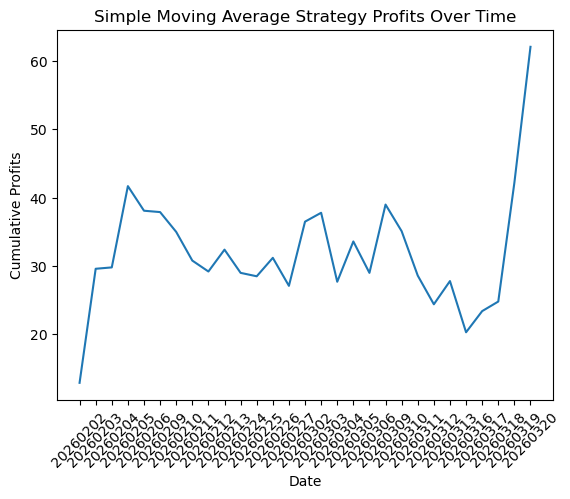

In [24]:
import matplotlib.pyplot as plt
simple['cumulative_profits'] = simple['profits'].cumsum()
plt.plot(simple['trade_ymd'], simple['cumulative_profits'])
plt.xlabel('Date')
plt.ylabel('Cumulative Profits')
plt.title('Simple Moving Average Strategy Profits Over Time')
plt.xticks(rotation=45)

In [25]:
from backtesting import backtest_summary
summary = backtest_summary(backtest_df)
print(summary)

{'交易天数': 29, '累计盈亏': np.float64(62.1), '最大单日盈利': 19.9, '最大单日亏损': -10.1, '盈利天数': 15, '亏损天数': 14, '平盘天数': 0, '胜率(%)': np.float64(51.72), '日均盈亏': np.float64(2.14), '盈亏比': np.float64(1.94)}


# 511520
threshold = 0.001
## 1200 3600 {'交易天数': 27, '累计盈亏': np.float64(84.3), '最大单日盈利': 17.6, '最大单日亏损': -5.0, '盈利天数': 15, '亏损天数': 12, '平盘天数': 0, '胜率(%)': np.float64(55.56), '日均盈亏': np.float64(3.12), '盈亏比': np.float64(3.51)}
## 2400 3600 {'交易天数': 29, '累计盈亏': np.float64(93.0), '最大单日盈利': 14.8, '最大单日亏损': -7.8, '盈利天数': 19, '亏损天数': 10, '平盘天数': 0, '胜率(%)': np.float64(65.52), '日均盈亏': np.float64(3.21), '盈亏比': np.float64(1.83)}
## 4800 7200 {'交易天数': 23, '累计盈亏': np.float64(77.2), '最大单日盈利': 18.0, '最大单日亏损': -3.8, '盈利天数': 14, '亏损天数': 8, '平盘天数': 1, '胜率(%)': np.float64(60.87), '日均盈亏': np.float64(3.36), '盈亏比': np.float64(4.16)}
## 1800 3600 {'交易天数': 28, '累计盈亏': np.float64(104.5), '最大单日盈利': 15.6, '最大单日亏损': -5.4, '盈利天数': 18, '亏损天数': 10, '平盘天数': 0, '胜率(%)': np.float64(64.29), '日均盈亏': np.float64(3.73), '盈亏比': np.float64(2.83)}

0
## 1800 3600 {'交易天数': 27, '累计盈亏': np.float64(119.7), '最大单日盈利': 18.4, '最大单日亏损': -4.2, '盈利天数': 18, '亏损天数': 9, '平盘天数': 0, '胜率(%)': np.float64(66.67), '日均盈亏': np.float64(4.43), '盈亏比': np.float64(3.62)}


# 511090
0
## 1800 3600 {'交易天数': 27, '累计盈亏': np.float64(80.1), '最大单日盈利': 79.2, '最大单日亏损': -44.0, '盈利天数': 14, '亏损天数': 13, '平盘天数': 0, '胜率(%)': np.float64(51.85), '日均盈亏': np.float64(2.97), '盈亏比': np.float64(1.27)}

# 518880
0
## 1800 3600 {'交易天数': 27, '累计盈亏': np.float64(56.3), '最大单日盈利': 19.9, '最大单日亏损': -10.1, '盈利天数': 14, '亏损天数': 13, '平盘天数': 0, '胜率(%)': np.float64(51.85), '日均盈亏': np.float64(2.09), '盈亏比': np.float64(1.91)}

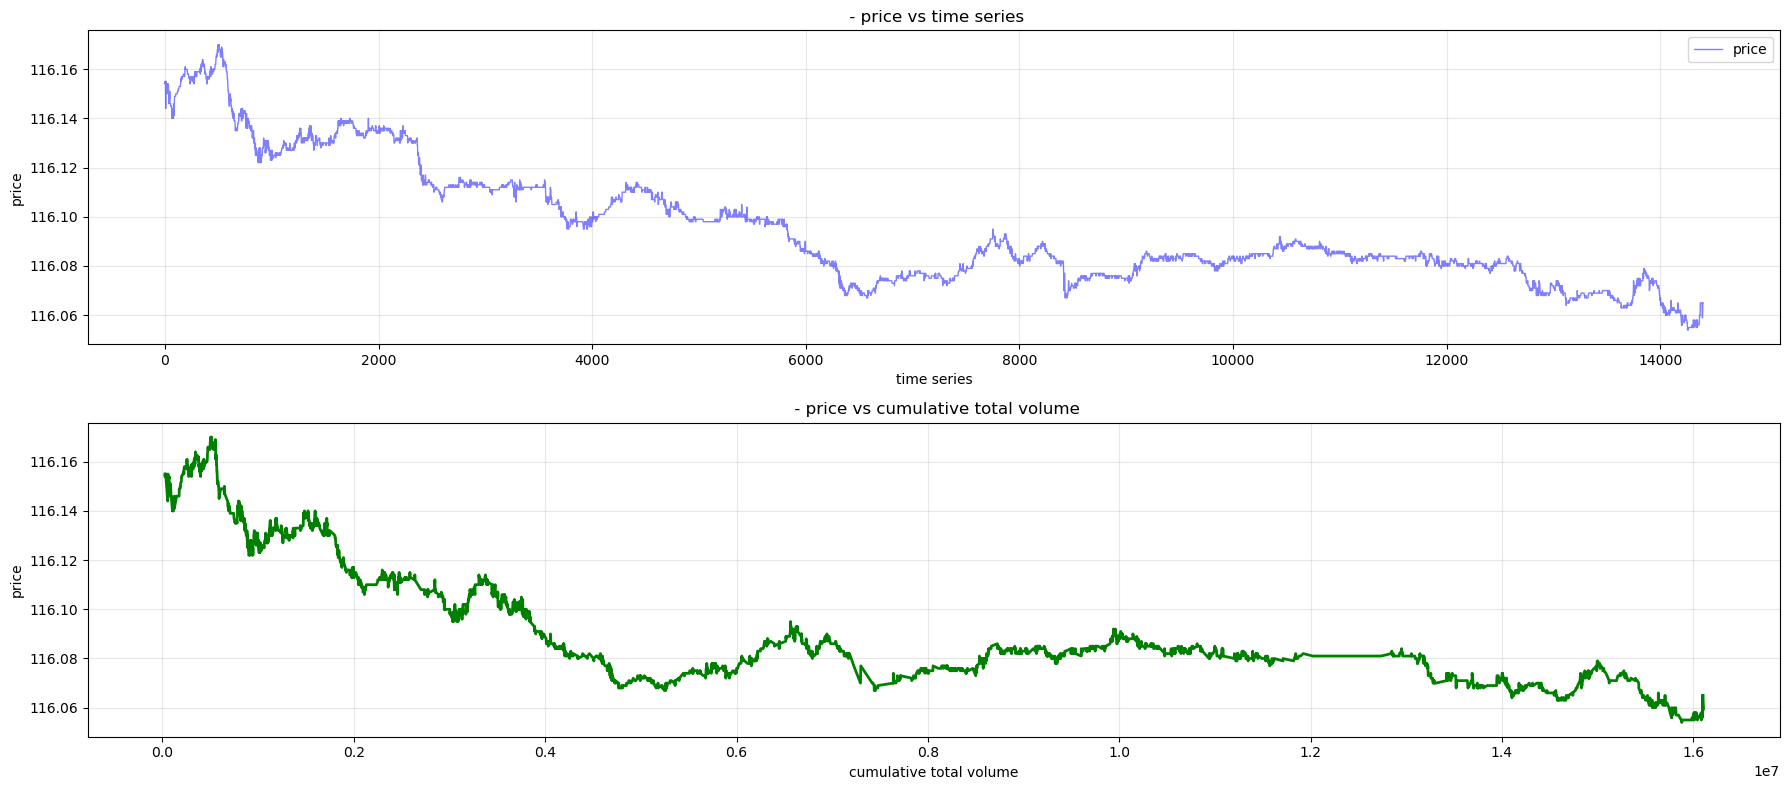

In [33]:
from plot_price import plot_price_analysis
import matplotlib.pyplot as plt
  

snap_list = base_tool.snap_list_load("511520", "20260320")
plot_price_analysis(snap_list)